In [1]:
import pandas as pd 
import numpy as np 
import sqlite3
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
conn = sqlite3.connect(r"C:\Users\Sumit Mathpal\Desktop\ML\Invoice_intelligent_system\Freight_cost_prediction\data\.db")


In [3]:
tables = pd.read_sql_query("select name from sqlite_master where type = 'table'",conn)
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [4]:
for table in tables["name"]:
    print("Table name",table)
    df = pd.read_sql_query(f"SELECT * FROM {table} limit 5", conn)
    display(df)

Table name purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table name begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [5]:
vendor_df = pd.read_sql_query("SELECT * FROM  vendor_invoice",conn)
vendor_df.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


In [6]:
vendor_df[["Quantity","Freight","Dollars"]].corr()

,Quantity,Freight,Dollars
Quantity,1.000000,0.946550,0.963831
Freight,0.946550,1.000000,0.985141
Dollars,0.963831,0.985141,1.000000


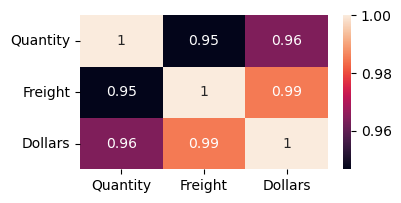

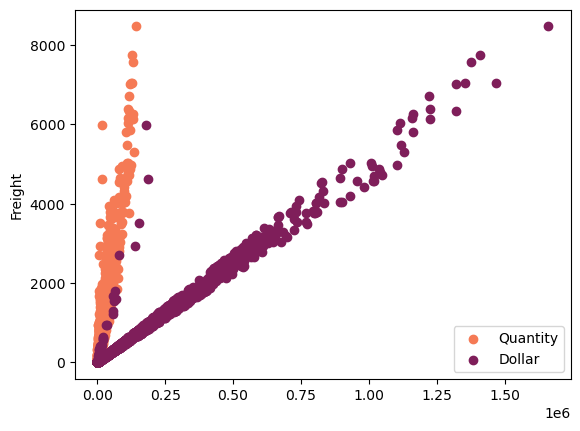

In [7]:
plt.figure(figsize=(4,2))
sns.heatmap(vendor_df[["Quantity","Freight","Dollars"]].corr(),annot=True)
plt.show()

plt.scatter(vendor_df["Quantity"],vendor_df["Freight"],color="#f57a55")
plt.scatter(vendor_df["Dollars"],vendor_df["Freight"],color="#7f1e5a")
plt.legend(["Quantity","Dollar"])
plt.ylabel("Freight")
plt.show()

In [8]:
vendor_df["Freight_per_unit"] = vendor_df["Freight"]/vendor_df["Quantity"]

In [9]:
vendor_df["Freight_per_unit"]

0       0.578333
1       0.571333
2       0.922000
3       0.290614
4       0.221809
          ...   
5538    0.095556
5539    0.040394
5540    0.094735
5541    0.033117
5542    0.037986
Name: Freight_per_unit, Length: 5543, dtype: float64

In [10]:
vendor_df

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval,Freight_per_unit
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None,0.578333
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None,0.571333
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None,0.922000
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None,0.290614
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None,0.221809
...,...,...,...,...,...,...,...,...,...,...,...
5538,9622,WEIN BAUER INC,2025-01-06,13626,2024-12-21,2025-02-10,90,1563.00,8.60,None,0.095556
5539,9625,WESTERN SPIRITS BEVERAGE CO,2025-01-10,13661,2024-12-23,2025-02-18,4617,37300.48,186.50,None,0.040394
5540,3664,WILLIAM GRANT & SONS INC,2025-01-02,13643,2024-12-22,2025-02-04,9848,202815.78,932.95,None,0.094735
5541,9815,WINE GROUP INC,2025-01-03,13602,2024-12-20,2025-02-08,24747,149007.56,819.54,None,0.033117


In [11]:
low_Quantile = vendor_df["Quantity"].quantile(0.25).mean()

In [12]:
print(low_Quantile)

83.0


In [13]:
high_Quantile = vendor_df["Quantity"].quantile(0.75).mean()

In [14]:
print(high_Quantile)

5100.5


In [15]:
print(vendor_df.loc[vendor_df["Quantity"]<low_Quantile,"Freight_per_unit"].mean())

0.09489854253138316


In [16]:
print(vendor_df.loc[vendor_df["Quantity"]>high_Quantile,"Freight_per_unit"].mean())

0.049077654690759046


In [17]:
X = vendor_df[["Dollars"]]
y= vendor_df["Freight"]

In [18]:
X

,Dollars
0,214.26
1,140.55
2,106.60
3,137483.78
4,15527.25
...,...
5538,1563.00
5539,37300.48
5540,202815.78
5541,149007.56


In [19]:
vendor_df.describe().round()

,VendorNumber,PONumber,Quantity,Dollars,Freight,Freight_per_unit
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,20663.0,10889.0,6059.0,58073.0,296.0,0.0
std,34582.0,1601.0,14453.0,140234.0,714.0,0.0
min,2.0,8106.0,1.0,4.0,0.0,0.0
25%,3089.0,9504.0,83.0,968.0,5.0,0.0
50%,7240.0,10890.0,423.0,4765.0,25.0,0.0
75%,10754.0,12276.0,5100.0,44587.0,230.0,0.0
max,201359.0,13661.0,141660.0,1660436.0,8468.0,3.0


In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=44)

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

In [23]:
model_LR = LinearRegression()
model_LR.fit(X_test,y_test)

model_DT = DecisionTreeRegressor(random_state=42)
model_DT.fit(X_test,y_test)

model_RF = RandomForestRegressor(random_state=42)
model_RF.fit(X_test,y_test)

RandomForestRegressor(random_state=42)

In [24]:
model_DT

DecisionTreeRegressor(random_state=42)

In [25]:
model_LR


LinearRegression()

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def model_evaluate(model, X_test, y_test, model_name):
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test,preds))
    r2 = r2_score(y_test, preds) * 100

    print(f"\n🔹 {model_name} Performance")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.2f}%")

    return mae, rmse, r2

In [27]:
model_evaluate(model_LR,X_test,y_test,'Linear Regression')


🔹 Linear Regression Performance
MAE  : 22.09
RMSE : 127.52
R²   : 97.18%


(22.0933934471866, np.float64(127.51784027719103), 97.17932723317584)

In [28]:
model_evaluate(model_DT,X_test,y_test,"Dicision tree")


🔹 Dicision tree Performance
MAE  : 0.00
RMSE : 0.03
R²   : 100.00%


(0.002628995090672276, np.float64(0.026313219729097604), 99.99999987989563)

In [29]:
model_evaluate(model_RF,X_test,y_test,"Random Forest")


🔹 Random Forest Performance
MAE  : 11.32
RMSE : 62.64
R²   : 99.32%


(11.317484740230947, np.float64(62.63648742771872), 99.31944128719121)

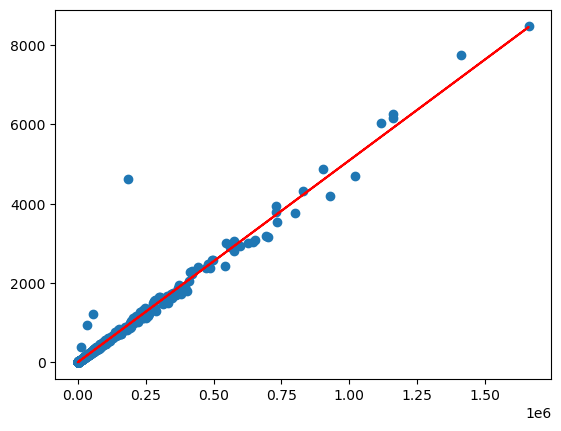

In [30]:
plt.scatter(X_test,y_test)
plt.plot(X_test,model_LR.predict(X_test), color='red')

In [31]:
input_data ={
    "Dollars":[18500,9000],
}

df = pd.DataFrame(input_data)

In [32]:
model_LR.predict(df)

array([95.26572351, 46.92274576])